In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [52]:
image = cv2.imread(r"data\d2.jpg")

if image is None:
    raise FileNotFoundError("image not found")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("RGB-image size:", image_rgb.shape)
print("grayscale-image size:", gray.shape)

RGB-image size: (2560, 1920, 3)
grayscale-image size: (2560, 1920)


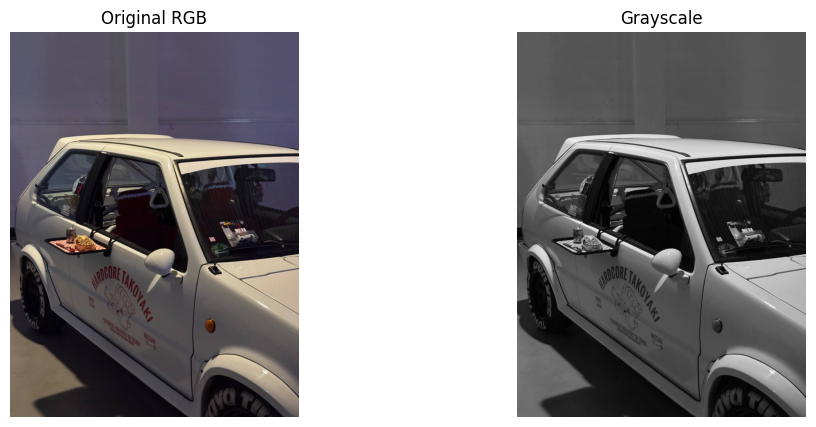

In [53]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.show()

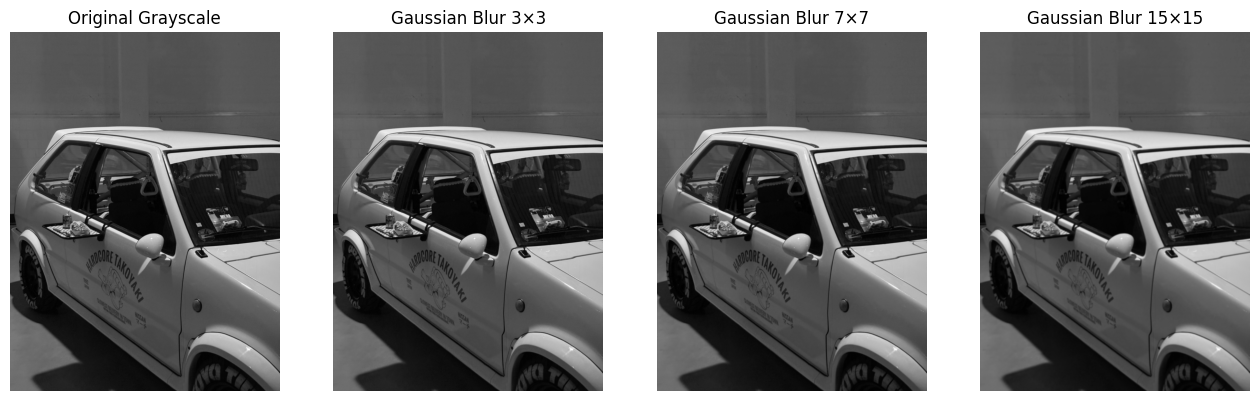

In [54]:
gaussian_3 = cv2.GaussianBlur(gray, (3, 3), 0)
gaussian_7 = cv2.GaussianBlur(gray, (7, 7), 0)
gaussian_15 = cv2.GaussianBlur(gray, (15, 15), 0)

plt.figure(figsize=(16, 5))

images = [
    (gray, "Original Grayscale"),
    (gaussian_3, "Gaussian Blur 3×3"),
    (gaussian_7, "Gaussian Blur 7×7"),
    (gaussian_15, "Gaussian Blur 15×15"),
]

for index, (img, title) in enumerate(images, start=1):
    plt.subplot(1, 4, index)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.show()

What does Gaussian Blur do?

- It reduces the impact of noise and small details. Each new pixel is calculated based on the neighboring pixels.

- The central pixels of the kernel usually have more weight than pixels at the edges.

The larger the kernel:
- the greater the blur;
- the fewer the small details;
- the easier it is to find large borders later;
- the higher the risk of losing important fine lines.

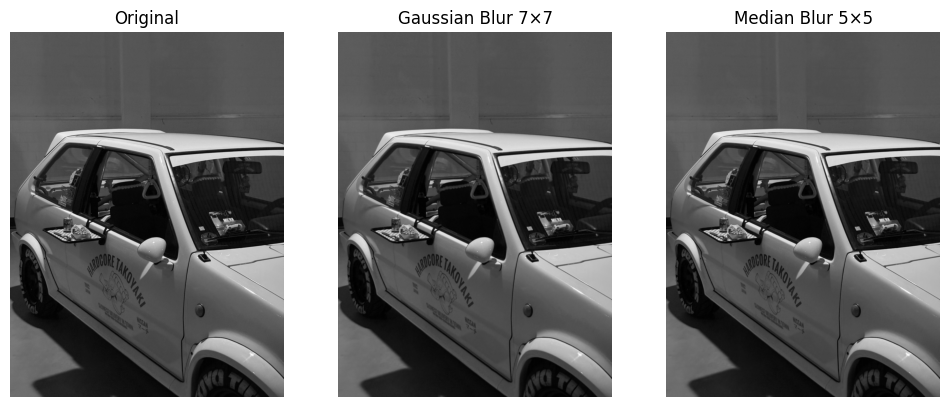

In [55]:
median_5 = cv2.medianBlur(gray, 5)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian_7, cmap="gray")
plt.title("Gaussian Blur 7×7")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(median_5, cmap="gray")
plt.title("Median Blur 5×5")
plt.axis("off")

plt.show()

The difference between Median Blur and Gaussian Blur

GaussianBlur calculates the weighted average of neighboring pixels.

medianBlur sorts neighboring pixels and selects the median value.

Example:

[10, 11, 10, 255, 12]

- Median
11

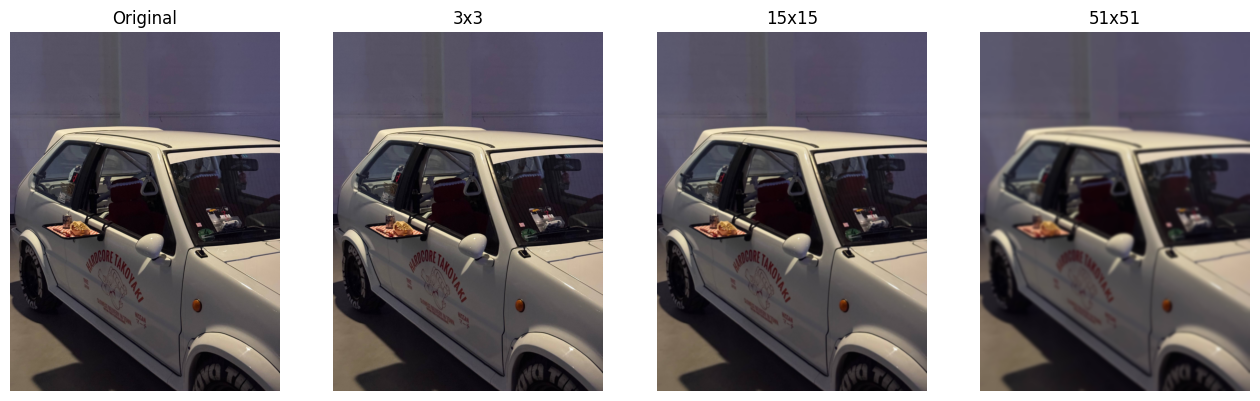

In [56]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"data\d2.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

blur_3 = cv2.GaussianBlur(img_rgb, (3, 3), 0)
blur_15 = cv2.GaussianBlur(img_rgb, (15, 15), 0)
blur_51 = cv2.GaussianBlur(img_rgb, (51, 51), 0)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(blur_3)
plt.title("3x3")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(blur_15)
plt.title("15x15")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(blur_51)
plt.title("51x51")
plt.axis("off")

plt.show()

When using Gaussian blur, the image is blurred, at 3*3 and 15*15 there are not much noticeable changes, but in the picture with blur 51*51 it is noticeable. Small random dots and grain were smoothed out almost immediately, and the text on the car as a whole. The sharp edges became softer with increasing degree of blur

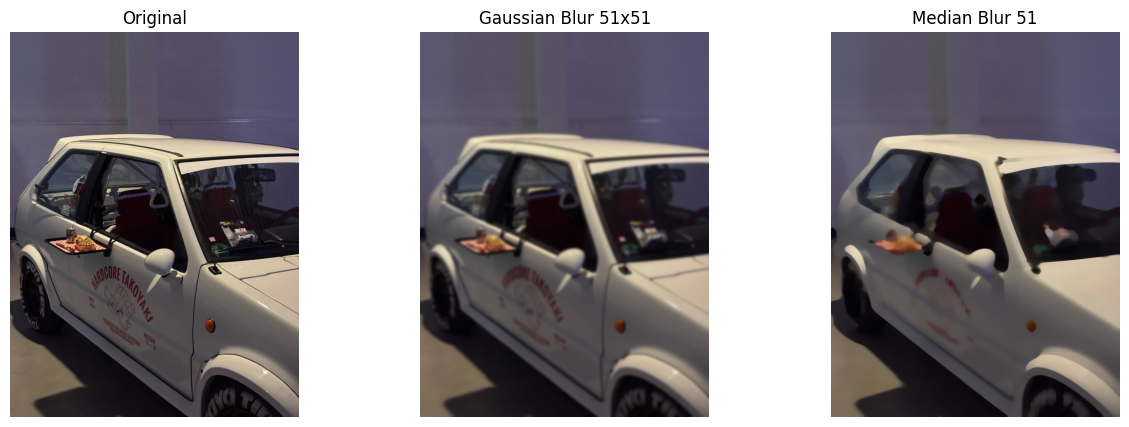

In [57]:
gaussian = cv2.GaussianBlur(img_rgb, (51, 51), 0)
median = cv2.medianBlur(img_rgb, 51)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian)
plt.title("Gaussian Blur 51x51")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(median)
plt.title("Median Blur 51")
plt.axis("off")

plt.show()

in comparing Gaussian and Median blur, we can observe that:
- Gaussian Blur → gently smears
- Median Blur → removes individual points better and preserves edges more often

Conclusion:

Heavy blurring worsens the result when useful details start to disappear along with the noise.

For Canny Edge Detection:  
If the blur is too strong, Canny stops finding thin boundaries.
- edges of the letter;
- fine lines;
- facial features;
- wires;
- small objects;
- borders between areas of similar color

# **Sobel, Laplacian и Canny**



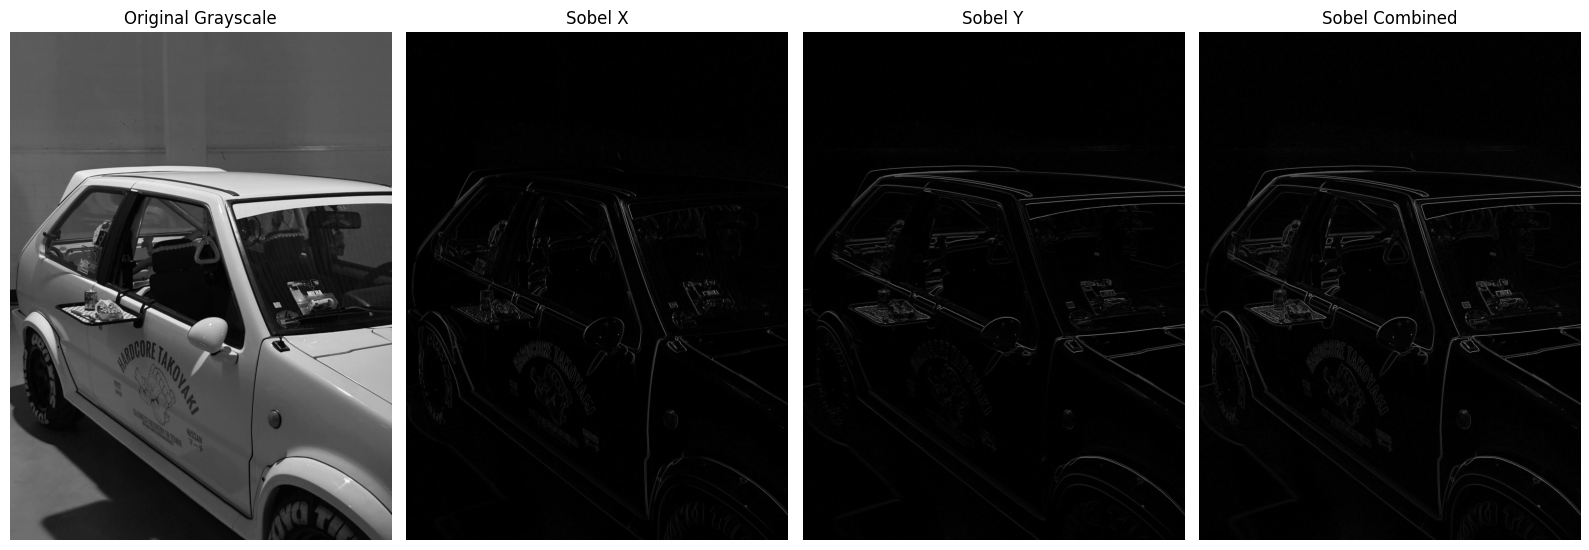

In [58]:
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

sobel_combined = cv2.magnitude(
    sobel_x.astype(np.float32),
    sobel_y.astype(np.float32)
)

plt.figure(figsize=(16, 6))

results = [
    (gray, "Original Grayscale"),
    (np.abs(sobel_x), "Sobel X"),
    (np.abs(sobel_y), "Sobel Y"),
    (sobel_combined, "Sobel Combined"),
]

for index, (img, title) in enumerate(results, start=1):
    plt.subplot(1, 4, index)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

Sobel X measures changes in brightness along the x-axis. Therefore, it responds particularly well to vertical edges.

In the image, the following elements should be noticeable:

* vertical window pillars;
* door edges;
* vertical sections of the car body.

Sobel Y measures changes in brightness along the y-axis. Therefore, it responds more strongly to horizontal edges:

* the roofline;
* the lower edge of the car body;
* the upper part of the hood;
* horizontal elements in the background.

Sobel Combined combines both directions.


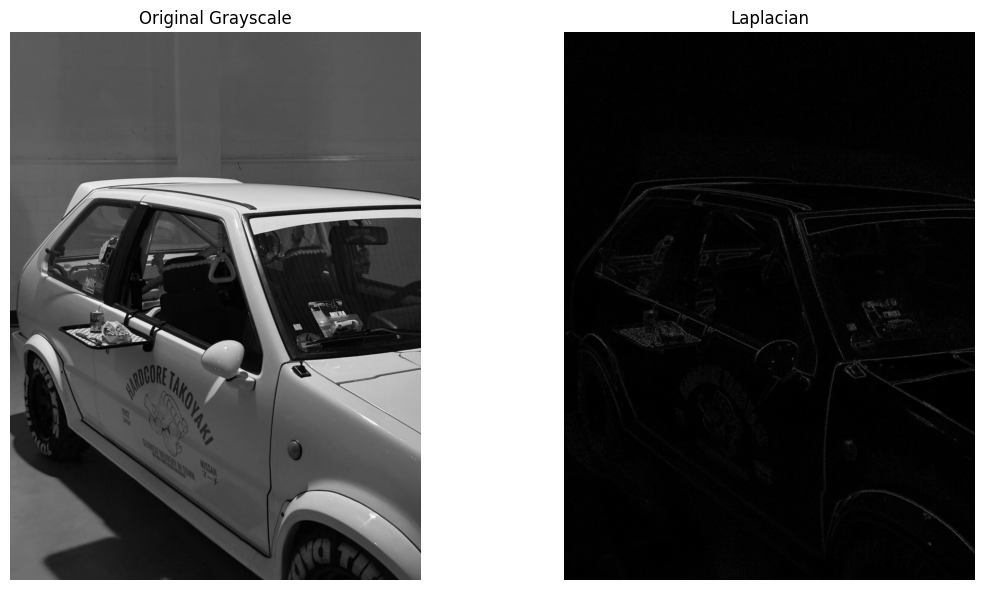

In [59]:
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.abs(laplacian), cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.tight_layout()
plt.show()

The Laplacian operator reacts to sharp changes in brightness in all directions. As a result, the output may appear noisier: in addition to useful edges, it also highlights fine textures, reflections, and background details.

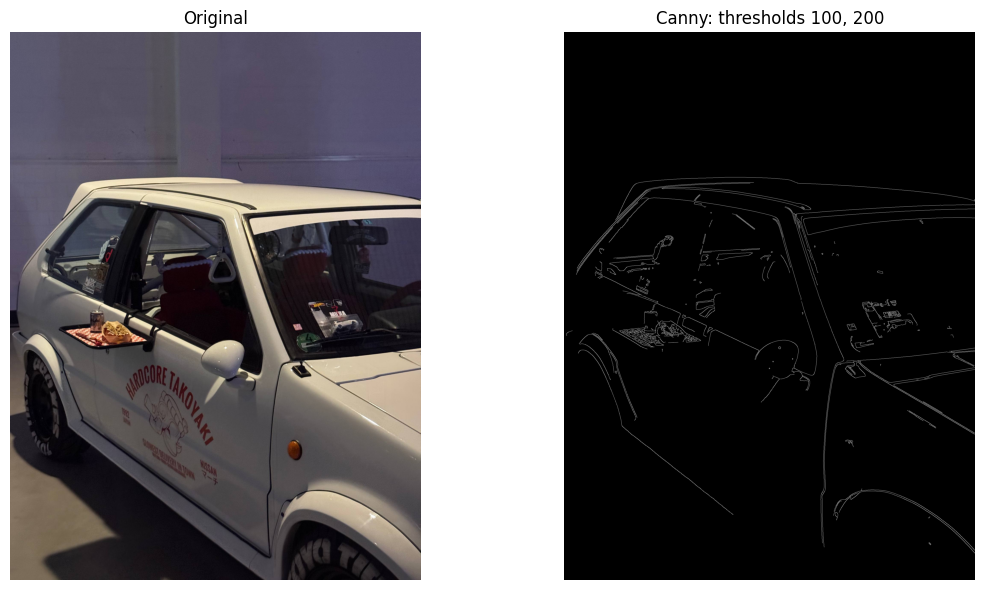

In [60]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

canny = cv2.Canny(blurred, 100, 200)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(canny, cmap="gray")
plt.title("Canny: thresholds 100, 200")
plt.axis("off")

plt.tight_layout()
plt.show()

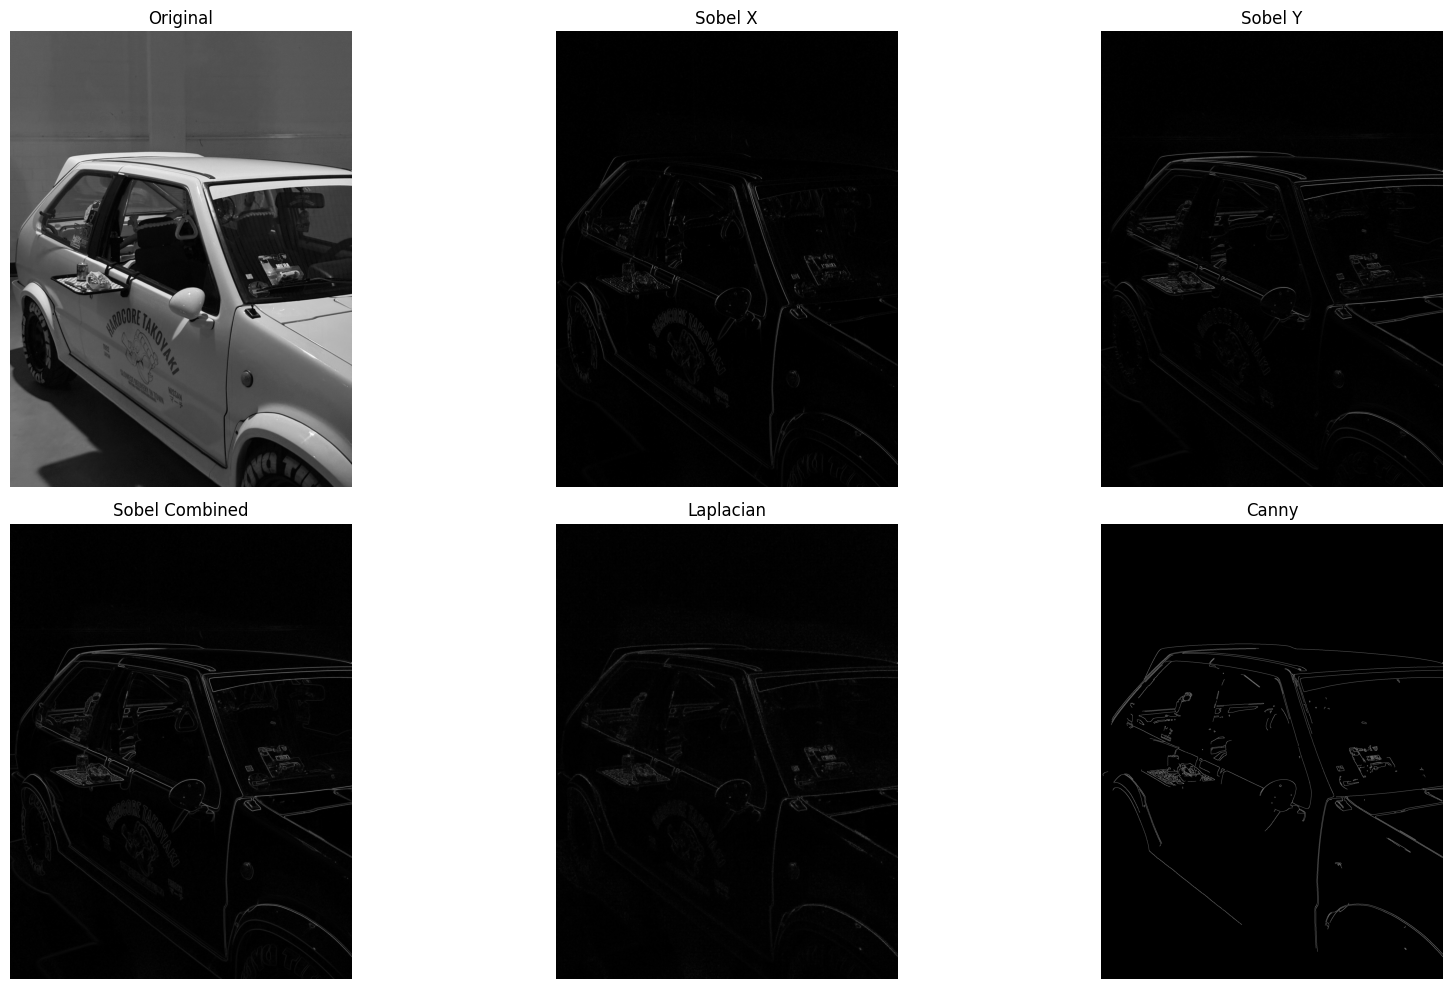

In [61]:
all_results = [
    (gray, "Original"),
    (np.abs(sobel_x), "Sobel X"),
    (np.abs(sobel_y), "Sobel Y"),
    (sobel_combined, "Sobel Combined"),
    (np.abs(laplacian), "Laplacian"),
    (canny, "Canny"),
]

plt.figure(figsize=(18, 10))

for index, (img, title) in enumerate(all_results, start=1):
    plt.subplot(2, 3, index)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Conclusions on Edge Detection


* In the Sobel X result, the vertical parts of the car are more noticeable. In the Sobel Y result, the horizontal parts of the car are more visible. The combined Sobel result shows the overall outline of the car.
* The Laplacian operator shows more fine lines and noise because it reacts to rapid changes in brightness in all directions and uses the second derivative of the image. The first derivative shows how quickly brightness changes between neighboring pixels. The second derivative shows how quickly the first derivative itself changes. In other words, it detects the point where the brightness change suddenly begins and then suddenly ends.
* Visually, the Canny result looks cleaner and thinner, while the combined Sobel result looks softer and thicker.
* However, Canny detects clear, high-contrast, and continuous edges well, while it may lose weak, blurred, and very thin edges.


# Comparison of Canny Thresholds

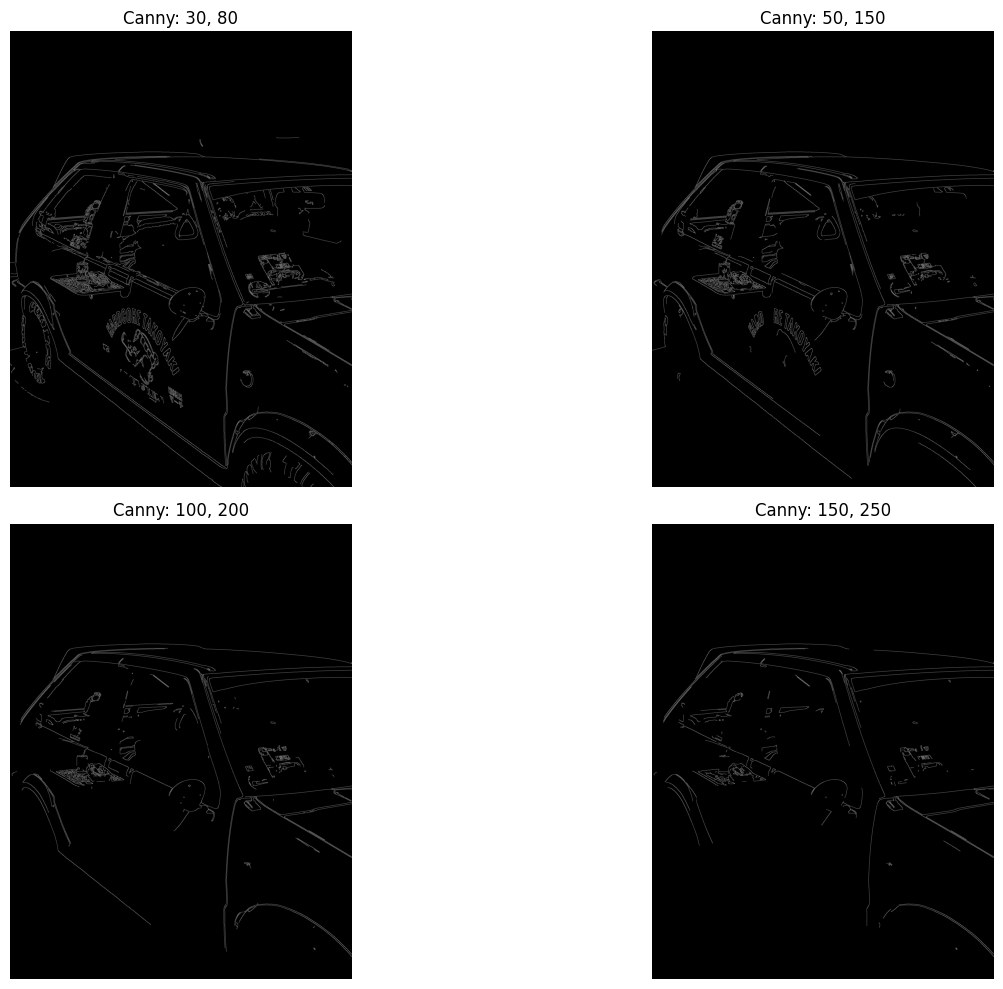

In [62]:
threshold_pairs = [
    (30, 80),
    (50, 150),
    (100, 200),
    (150, 250),
]

plt.figure(figsize=(16, 10))

for index, (threshold_1, threshold_2) in enumerate(threshold_pairs, start=1):
    edges = cv2.Canny(blurred, threshold_1, threshold_2)

    plt.subplot(2, 2, index)
    plt.imshow(edges, cmap="gray")
    plt.title(f"Canny: {threshold_1}, {threshold_2}")
    plt.axis("off")

plt.tight_layout()
plt.show()

With Canny thresholds of 30–80, too many unnecessary elements are detected. The 50–150 range gives a better result, but some small irrelevant details are still present. For this particular image, 100–200 is the best option, because with 150–250 we begin to lose useful details. There is no single pair of Canny thresholds that works well for every image, since different images vary in brightness, contrast, noise level, and the amount of fine detail.

# Manual convolution

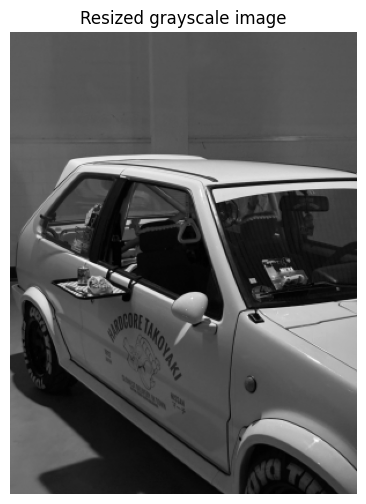

In [63]:
small_gray = cv2.resize(
    gray,
    (300, 400),
    interpolation=cv2.INTER_AREA
)

plt.figure(figsize=(5, 6))
plt.imshow(small_gray, cmap="gray")
plt.title("Resized grayscale image")
plt.axis("off")
plt.show()

In [64]:
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

In [65]:
def apply_convolution(image, kernel):
    image = image.astype(np.float32)

    kernel_height, kernel_width = kernel.shape
    padding_y = kernel_height // 2
    padding_x = kernel_width // 2

    padded_image = np.pad(
        image,
        ((padding_y, padding_y), (padding_x, padding_x)),
        mode="constant"
    )

    output = np.zeros_like(image, dtype=np.float32)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            region = padded_image[
                y:y + kernel_height,
                x:x + kernel_width
            ]

            output[y, x] = np.sum(region * kernel)

    return output

In [66]:
manual_result = apply_convolution(small_gray, kernel)

In [67]:
opencv_result = cv2.filter2D(
    small_gray.astype(np.float32),
    ddepth=cv2.CV_32F,
    kernel=kernel,
    borderType=cv2.BORDER_CONSTANT
)

difference = np.abs(manual_result - opencv_result)

print("Maximum difference:", difference.max())
print("Average difference:", difference.mean())

Maximum difference: 0.0
Average difference: 0.0


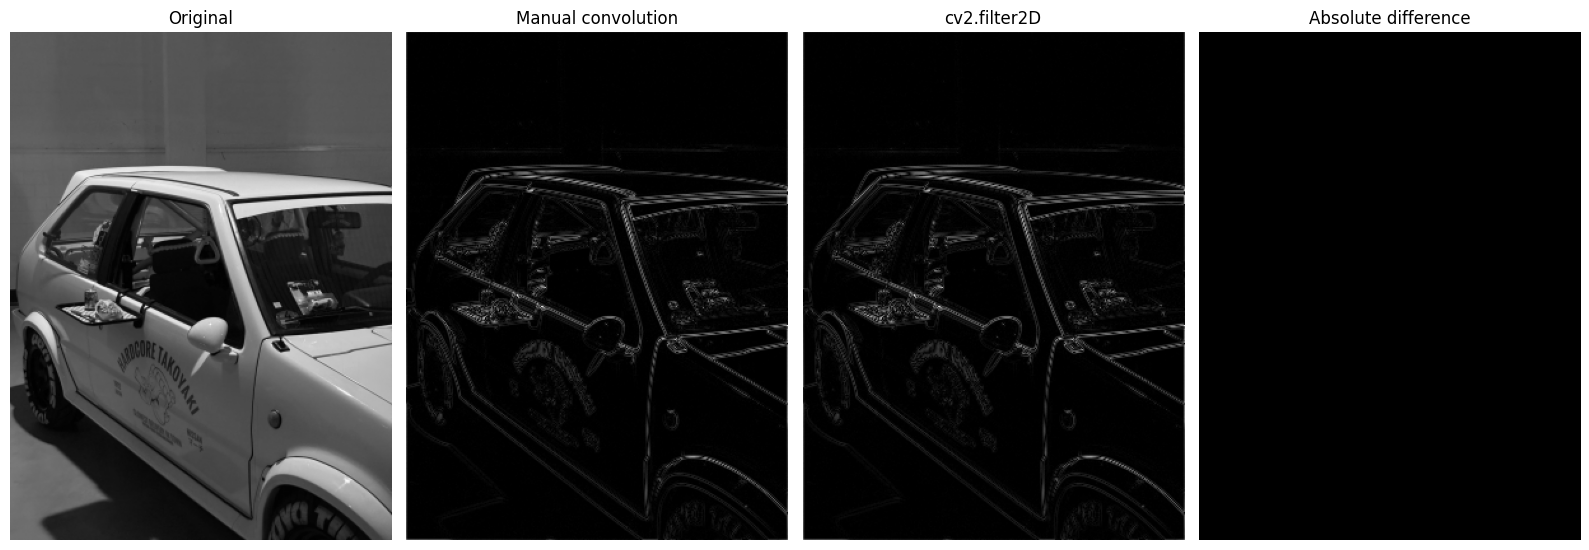

In [68]:
comparison = [
    (small_gray, "Original"),
    (np.abs(manual_result), "Manual convolution"),
    (np.abs(opencv_result), "cv2.filter2D"),
    (difference, "Absolute difference"),
]

plt.figure(figsize=(16, 6))

for index, (img, title) in enumerate(comparison, start=1):
    plt.subplot(1, 4, index)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

Padding is needed to create additional pixels around the edges of an image before applying convolution. Without it, the image would become smaller after each pass of the filter. Padding allows us to preserve the original image size and process the pixels located near the borders.

Different kernels are responsible for different operations, such as blurring, sharpening, and detecting vertical or horizontal edges.

A kernel can also contain negative coefficients. During convolution, the values of neighboring pixels are multiplied by the kernel coefficients and then summed. If the contribution of the negative coefficients is greater than that of the positive ones, the result will be negative. These values are useful because they can indicate the direction of brightness changes.

We obtained an identical result in both cases.The manual function and `cv2.filter2D` perform cross-correlation because the kernel is not flipped before applying it to the image. In this experiment, the result is the same as convolution because the selected kernel is symmetric. 

However, the manual implementation is usually slower than OpenCV because Python code often uses nested loops over pixels, and Python executes such loops slowly. `cv2.filter2D` is implemented in C/C++ and uses more efficient computation methods, as well as vectorization and hardware optimizations in some cases. Therefore, OpenCV is noticeably faster.

